### Решение задачи поиска минимума

1. **Полный перебор (Brute Force)**
   * **Суть**: Интервал разбивается на $N$ равных частей, функция вычисляется в каждой точке. Выбирается точка с минимальным значением.
   * **Сложность**: $O(N)$, где $N$ — количество точек сетки. 
   * **Плюсы/Минусы**: Гарантированно находит глобальный минимум (если сетка достаточно густая, а функция унимодальна), но крайне неэффективен. Требует $N$ вычислений функции.

2. **Дихотомия**
   * **Суть**: На каждом шаге выбираются две точки, симметричные центру отрезка (разделенные на малую величину $\delta$). Отрезок сокращается вдвое в зависимости от того, в какой точке значение меньше.
   * **Сложность**: $O(\log_2(\frac{b-a}{\varepsilon}))$. 
   * **Плюсы/Минусы**: Прост в реализации. Требует 2 вычисления функции на каждом шаге (кроме первого, где нужно 2, далее по 2, так как точки не совпадают с предыдущими).

3. **Золотое сечение**
   * **Суть**: Улучшение дихотомии. Точки делят отрезок в пропорции золотого сечения ($\approx 0.618$). При сокращении отрезка одна из старых точек автоматически становится новой точкой золотого сечения.
   * **Сложность**: $O(\log_\phi(\frac{b-a}{\varepsilon}))$, где $\phi \approx 1.618$.
   * **Плюсы/Минусы**: Требует только **1 вычисление** функции на каждом шаге (после начальной инициализации). Самый эффективный из методов прямого поиска.

4. **Метод парабол**
   * **Суть**: Через 3 текущие точки строится парабола. Ее минимум используется как следующая тестируемая точка. Точки обновляются, чтобы сохранять унимодальность.
   * **Сложность**: Теоретически имеет сверхлинейную сходимость (порядка $\approx 1.32$) для гладких функций.
   * **Плюсы/Минусы**: Сходится быстрее методов деления отрезка, но требует 3 вычислений на старте и может "буксовать", если функция плохо аппроксимируется параболой.

In [50]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

### Аналитический способ проверки унимодальности функции
Самый надежный метод. Функция $f(x)$ унимодальна на $[a, b]$, если:
1. Уравнение $f'(x) = 0$ имеет **ровно один** корень на этом отрезке.
2. Вторая производная $f''(x) > 0$ в этой точке (или $f'(x)$ меняет знак с минуса на плюс).

In [51]:
# Проверка унимодальности функции
def is_unimodal(f, a, b, n=10000):
    x = np.linspace(a, b, n)
    y = np.asarray(f(x), dtype=float)

    # Проверяем корректность значений функции
    if not np.all(np.isfinite(y)):
        return False

    # Приращения функции
    dy = np.diff(y)

    # Убираем участки, где функция практически не меняется
    eps = 1e-12
    dy[np.abs(dy) < eps] = 0

    # Знаки приращений
    signs = np.sign(dy)

    # Убираем нулевые значения
    signs = signs[signs != 0]

    if len(signs) == 0:
        # Постоянная функция
        return True

    has_minimum = np.all(np.diff(signs) >= 0)
    has_maximum = np.all(np.diff(signs) <= 0)

    return has_minimum or has_maximum


### Ввод значений, который будут анализироваться
- func - функция, которую желаем анализировать
- [a, b] - промежуток, на котором будет анализироваться func - функция

### Проверка УНИМОДАЛЬНОСТИ введенной функции на промежутке

In [52]:
func = input('Введите функцию, у которой желаете найти минимум: ')
a, b = map(float, input('Введите промежуток (a b): ').split())
print(f'Ваша функция: {func}')

x = sp.symbols('x')
expr = sp.sympify(func)      
f = sp.lambdify(x, expr, 'numpy') 

if is_unimodal(f, a, b):
    print(f'Функция {func} на промежутке [{a}, {b}] УНИМОДАЛЬНА')
else:     
    print(f'Функция {func} на промежутке [{a}, {b}] НЕ УНИМОДАЛЬНА')


Ваша функция: x**2 - 2*x
Функция x**2 - 2*x на промежутке [-10.0, 10.0] УНИМОДАЛЬНА


### Методы поиска минимума

In [53]:
class Counter:
    def __init__(self, func):
        self.func = func
        self.calls = 0
    def __call__(self, x):
        self.calls += 1
        return self.func(x)

# 1. Полный перебор
def brute_force(f, a, b, n=1000):
    xs = np.linspace(a, b, n)
    return min(xs, key=f)

# 2. Дихотомия
def dichotomy(f, a, b, eps=1e-5):
    delta = eps / 3
    while b - a > eps:
        x1, x2 = (a + b) / 2 - delta, (a + b) / 2 + delta
        if f(x1) < f(x2): b = x2
        else: a = x1
    return (a + b) / 2

# 3. Золотое сечение
def golden_section(f, a, b, eps=1e-5):
    phi = (5**0.5 - 1) / 2
    x1 = b - phi * (b - a)
    x2 = a + phi * (b - a)
    f1, f2 = f(x1), f(x2)
    
    while b - a > eps:
        if f1 < f2:
            b = x2
            x2 = x1
            f2 = f1             # Переиспользуем старое значение!
            x1 = b - phi * (b - a)
            f1 = f(x1)          # Только 1 новый вызов
        else:
            a = x1
            x1 = x2
            f1 = f2             # Переиспользуем старое значение!
            x2 = a + phi * (b - a)
            f2 = f(x2)          # Только 1 новый вызов
            
    return (a + b) / 2

# 4. Метод парабол
def parabola_method(f, a, b, eps=1e-5, max_iter=1000):
    x1 = a
    x2 = (a + b) / 2
    x3 = b

    f1 = f(x1)
    f2 = f(x2)
    f3 = f(x3)

    for _ in range(max_iter):

        if f1 <= f2 and f1 <= f3:
            pass

        den = ((x2 - x3) * f1 + (x3 - x1) * f2 + (x1 - x2) * f3)

 
        if abs(den) < 1e-14:
            points = [(x1, f1), (x2, f2), (x3, f3)]
            return min(points, key=lambda p: p[1])[0]

        num = ((x2**2 - x3**2) * f1 + (x3**2 - x1**2) * f2 + (x1**2 - x2**2) * f3)

        x_new = 0.5 * num / den

        # Если парабола дала точку за пределами интервала
        if not (a <= x_new <= b):
            points = [(x1, f1), (x2, f2), (x3, f3)]
            return min(points, key=lambda p: p[1])[0]

        f_new = f(x_new)

        # Критерий остановки
        if abs(x_new - x2) < eps:
            return x_new

        points = [(x1, f1), (x2, f2), (x3, f3), (x_new, f_new)]

        points.sort(key=lambda p: p[0])

        # Ищем точку с минимальным значением
        min_index = min(range(len(points)), key=lambda i: points[i][1])

        if min_index == 0:
            return points[0][0]

        if min_index == len(points) - 1:
            return points[-1][0]

        # Берём три точки вокруг текущего минимума
        x1, f1 = points[min_index - 1]
        x2, f2 = points[min_index]
        x3, f3 = points[min_index + 1]

    # Если достигли max_iter,
    # возвращаем лучшую найденную точку
    points = [(x1, f1), (x2, f2), (x3, f3)]
    return min(points, key=lambda p: p[1])[0]


In [54]:
methods = {
    "Полный перебор": lambda f: brute_force(f, a, b),
    "Дихотомия": lambda f: dichotomy(f, a, b),
    "Золотое сечение": lambda f: golden_section(f, a, b),
    "Метод парабол": lambda f: parabola_method(f, a, b)
}

results = {}
print(f"{'Метод':<20} | {'x_min':<15} | {'f(x_min)':<15} | {'Вызовов f(x)'}")
print("-" * 60)

for name, method in methods.items():
    f_counted = Counter(f)
    x_min = method(f_counted)
    results[name] = x_min
    print(f"{name:<20} | {x_min:<15.6f} | {f(x_min):<15.6f} | {f_counted.calls}")

Метод                | x_min           | f(x_min)        | Вызовов f(x)
------------------------------------------------------------
Полный перебор       | 0.990991        | -0.999919       | 1000
Дихотомия            | 1.000000        | -1.000000       | 46
Золотое сечение      | 1.000000        | -1.000000       | 33
Метод парабол        | 1.000000        | -1.000000       | 5


### Отображение результатов на графиках
1. Полный перебор
2. Дихотомия
3. Золотое сечение
4. Метод парабол

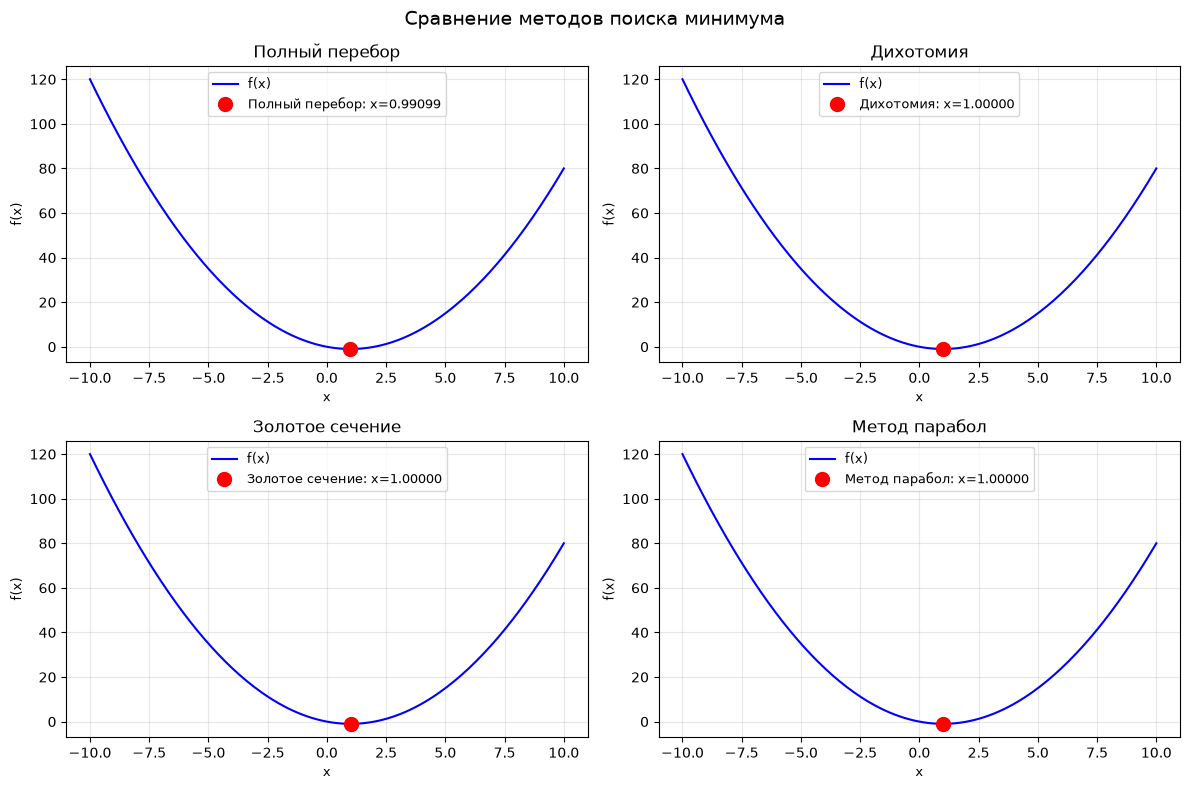

In [55]:
x_vals = np.linspace(a, b, 200)
y_vals = f(x_vals)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (name, x_min) in enumerate(results.items()):
    ax = axes[i]
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=1.5, label='f(x)')
    
    # Отмечаем найденный минимум
    ax.plot(x_min, f(x_min), 'o', color='red', markersize=10, label=f'{name}: x={x_min:.5f}')
    
    # Оформление
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("x", fontsize=9)
    ax.set_ylabel("f(x)", fontsize=9)
    ax.legend(loc='upper center', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Сравнение методов поиска минимума", fontsize=14)
plt.tight_layout()
plt.show()